# Lab 11: Linear Regression

## Insurance Charges Analysis

This notebook uses linear regression to investigate relationships between selected patient characteristics and annual medical insurance charges. Two separate regression models will be developed, evaluated, and visualized.

In [1]:
# Install xlrd so Pandas can read the older .xls Excel format
%pip install xlrd -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Import libraries for data handling and visualization
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the path to the insurance dataset
data_path = Path("Lab 11 - Insurance.xls")

# Confirm that the dataset exists
print(f"Dataset path: {data_path.resolve()}")
print(f"Dataset exists: {data_path.exists()}")

Dataset path: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_11_Linear_Regression\Lab 11 - Insurance.xls
Dataset exists: True


In [3]:
# Load the Insurance worksheet into a Pandas DataFrame
insurance_df = pd.read_excel(
    data_path,
    sheet_name="Insurance",
    engine="xlrd"
)

print("Insurance dataset loaded successfully.")

Insurance dataset loaded successfully.


In [4]:
# Display the first 10 records in the dataset
insurance_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 1. Dataset Overview and Data Quality

Before developing the regression models, the dataset is examined to understand its size, variables, data types, missing values, duplicates, and descriptive statistics.

In [5]:
# Display the number of rows and columns
print(f"Number of rows: {insurance_df.shape[0]}")
print(f"Number of columns: {insurance_df.shape[1]}")

# Display the column names
print("\nDataset columns:")
for column in insurance_df.columns:
    print(f"- {column}")

Number of rows: 1338
Number of columns: 7

Dataset columns:
- age
- sex
- bmi
- children
- smoker
- region
- charges


In [6]:
# Display information about the dataset, including data types
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
# Count missing values in each column
missing_values = insurance_df.isnull().sum()

# Count duplicated rows
duplicate_count = insurance_df.duplicated().sum()

print("Missing values by column:")
print(missing_values)

print(f"\nNumber of duplicated rows: {duplicate_count}")

Missing values by column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Number of duplicated rows: 1


In [8]:
# Remove duplicate records and create a clean copy of the dataset
insurance_clean_df = insurance_df.drop_duplicates().copy()

print(f"Original number of rows: {insurance_df.shape[0]}")
print(f"Rows after removing duplicates: {insurance_clean_df.shape[0]}")
print(f"Duplicates remaining: {insurance_clean_df.duplicated().sum()}")

Original number of rows: 1338
Rows after removing duplicates: 1337
Duplicates remaining: 0


In [9]:
# Generate descriptive statistics for the numerical variables
numerical_summary = insurance_clean_df.describe().round(2)

numerical_summary

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [10]:
# Display frequency counts for categorical variables
categorical_columns = ["sex", "smoker", "region"]

for column in categorical_columns:
    print(f"\nFrequency distribution for '{column}':")
    print(insurance_clean_df[column].value_counts())


Frequency distribution for 'sex':
sex
male      675
female    662
Name: count, dtype: int64

Frequency distribution for 'smoker':
smoker
no     1063
yes     274
Name: count, dtype: int64

Frequency distribution for 'region':
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 2. Research Questions and Hypotheses

This analysis investigates whether age and body mass index are associated with annual medical insurance charges.

### Research Question 1

**Does an insured person’s age significantly predict annual medical insurance charges?**

* **Null hypothesis (H₀):** Age does not have a statistically significant linear relationship with insurance charges. The age regression coefficient equals zero.
* **Alternative hypothesis (H₁):** Age has a statistically significant linear relationship with insurance charges. The age regression coefficient does not equal zero.

### Research Question 2

**Does an insured person’s body mass index significantly predict annual medical insurance charges?**

* **Null hypothesis (H₀):** BMI does not have a statistically significant linear relationship with insurance charges. The BMI regression coefficient equals zero.
* **Alternative hypothesis (H₁):** BMI has a statistically significant linear relationship with insurance charges. The BMI regression coefficient does not equal zero.

A significance level of **α = 0.05** will be used. The null hypothesis will be rejected when the predictor’s p-value is less than 0.05.


In [11]:
# Define the predictor and outcome variables used in the analysis
predictor_columns = ["age", "bmi"]
target_column = "charges"

# Display descriptive statistics for the selected variables
selected_summary = (
    insurance_clean_df[predictor_columns + [target_column]]
    .describe()
    .round(2)
)

selected_summary

,age,bmi,charges
count,1337.00,1337.00,1337.00
mean,39.22,30.66,13279.12
std,14.04,6.10,12110.36
min,18.00,15.96,1121.87
25%,27.00,26.29,4746.34
50%,39.00,30.40,9386.16
75%,51.00,34.70,16657.72
max,64.00,53.13,63770.43


In [12]:
# Calculate Pearson correlations among age, BMI, and insurance charges
correlation_matrix = (
    insurance_clean_df[["age", "bmi", "charges"]]
    .corr()
    .round(3)
)

print("Correlation matrix:")
correlation_matrix

Correlation matrix:


,age,bmi,charges
age,1.000,0.109,0.298
bmi,0.109,1.000,0.198
charges,0.298,0.198,1.000


In [13]:
# Create the output directory if it does not already exist
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {output_dir.resolve()}")

Output directory: C:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_11_Linear_Regression\outputs


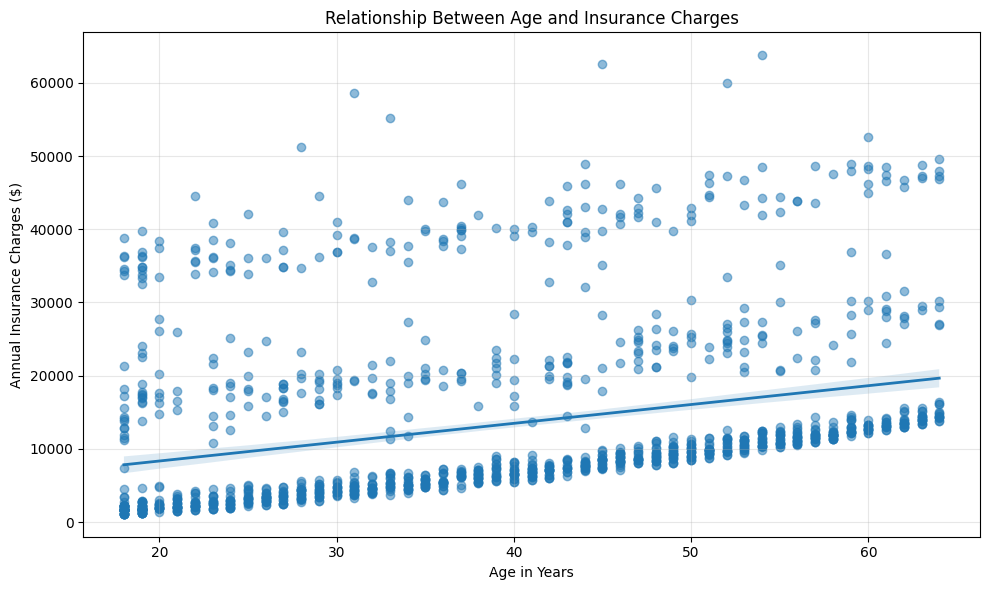

In [14]:
# Create a scatter plot with a preliminary regression line
plt.figure(figsize=(10, 6))

sns.regplot(
    data=insurance_clean_df,
    x="age",
    y="charges",
    scatter_kws={"alpha": 0.50},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between Age and Insurance Charges")
plt.xlabel("Age in Years")
plt.ylabel("Annual Insurance Charges ($)")
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure for use in the written report
plt.savefig(
    output_dir / "age_vs_charges_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

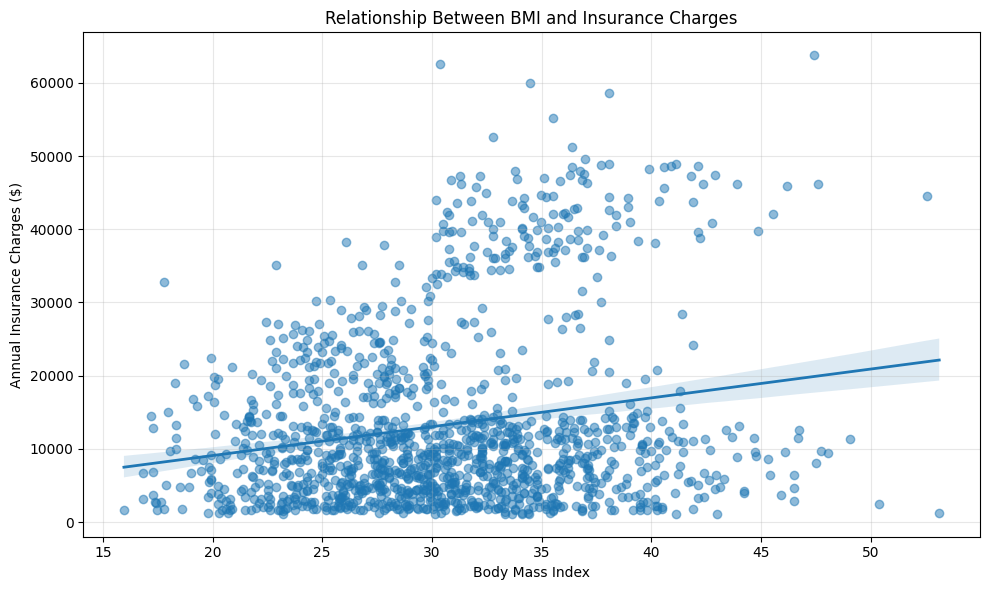

In [15]:
# Create a scatter plot with a preliminary regression line
plt.figure(figsize=(10, 6))

sns.regplot(
    data=insurance_clean_df,
    x="bmi",
    y="charges",
    scatter_kws={"alpha": 0.50},
    line_kws={"linewidth": 2}
)

plt.title("Relationship Between BMI and Insurance Charges")
plt.xlabel("Body Mass Index")
plt.ylabel("Annual Insurance Charges ($)")
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure for use in the written report
plt.savefig(
    output_dir / "bmi_vs_charges_scatterplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Linear Regression Method

Simple linear regression examines the relationship between one numerical predictor and one continuous outcome variable. The general regression equation is:

[
\hat{y} = \beta_0 + \beta_1x
]

where:

* (\hat{y}) is the predicted insurance charge.
* (\beta_0) is the intercept.
* (\beta_1) is the estimated change in insurance charges associated with a one-unit increase in the predictor.
* (x) is either age or BMI.

Ordinary Least Squares regression estimates the coefficients by minimizing the sum of squared differences between observed and predicted values. Statsmodels is used because it provides inferential statistics needed to evaluate the null and alternative hypotheses.


In [16]:
# Import Statsmodels for regression analysis
import statsmodels.api as sm

# Import model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Regression libraries imported successfully.")

Regression libraries imported successfully.


In [17]:
# Define age as the predictor variable
X_age = insurance_clean_df[["age"]]

# Add a constant column to estimate the regression intercept
X_age = sm.add_constant(X_age)

# Define insurance charges as the outcome variable
y_charges = insurance_clean_df["charges"]

# Fit an Ordinary Least Squares linear regression model
age_model = sm.OLS(y_charges, X_age).fit()

print("Age regression model fitted successfully.")

Age regression model fitted successfully.


In [18]:
# Display the complete statistical summary for the age model
print(age_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     130.4
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           6.98e-29
Time:                        13:48:47   Log-Likelihood:                -14405.
No. Observations:                1337   AIC:                         2.881e+04
Df Residuals:                    1335   BIC:                         2.882e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3190.0217    938.396      3.399      0.0

In [19]:
# Generate predicted insurance charges using the age model
insurance_clean_df["age_predicted_charges"] = age_model.predict(X_age)

# Calculate residuals as actual charges minus predicted charges
insurance_clean_df["age_residuals"] = (
    insurance_clean_df["charges"]
    - insurance_clean_df["age_predicted_charges"]
)

# Calculate model evaluation measures
age_mae = mean_absolute_error(
    insurance_clean_df["charges"],
    insurance_clean_df["age_predicted_charges"]
)

age_rmse = np.sqrt(
    mean_squared_error(
        insurance_clean_df["charges"],
        insurance_clean_df["age_predicted_charges"]
    )
)

age_intercept = age_model.params["const"]
age_coefficient = age_model.params["age"]
age_p_value = age_model.pvalues["age"]
age_r_squared = age_model.rsquared

print("MODEL 1: AGE PREDICTING INSURANCE CHARGES")
print("-" * 50)
print(
    f"Regression equation: Predicted Charges = "
    f"{age_intercept:.2f} + ({age_coefficient:.2f} × Age)"
)
print(f"Age coefficient: ${age_coefficient:,.2f}")
print(f"Age p-value: {age_p_value:.6e}")
print(f"R-squared: {age_r_squared:.4f}")
print(f"Mean Absolute Error: ${age_mae:,.2f}")
print(f"Root Mean Squared Error: ${age_rmse:,.2f}")

if age_p_value < 0.05:
    print("\nDecision: Reject the null hypothesis.")
    print("Age is a statistically significant predictor of insurance charges.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("Age is not a statistically significant predictor of insurance charges.")

MODEL 1: AGE PREDICTING INSURANCE CHARGES
--------------------------------------------------
Regression equation: Predicted Charges = 3190.02 + (257.23 × Age)
Age coefficient: $257.23
Age p-value: 6.975749e-29
R-squared: 0.0890
Mean Absolute Error: $9,059.15
Root Mean Squared Error: $11,554.65

Decision: Reject the null hypothesis.
Age is a statistically significant predictor of insurance charges.


In [20]:
# Define BMI as the predictor variable
X_bmi = insurance_clean_df[["bmi"]]

# Add a constant column to estimate the regression intercept
X_bmi = sm.add_constant(X_bmi)

# Fit an Ordinary Least Squares linear regression model
bmi_model = sm.OLS(y_charges, X_bmi).fit()

print("BMI regression model fitted successfully.")

BMI regression model fitted successfully.


In [21]:
# Display the complete statistical summary for the BMI model
print(bmi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.70
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.47e-13
Time:                        13:51:00   Log-Likelihood:                -14440.
No. Observations:                1337   AIC:                         2.888e+04
Df Residuals:                    1335   BIC:                         2.889e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1202.1404   1664.857      0.722      0.4

In [22]:
# Generate predicted insurance charges using the BMI model
insurance_clean_df["bmi_predicted_charges"] = bmi_model.predict(X_bmi)

# Calculate BMI model residuals
insurance_clean_df["bmi_residuals"] = (
    insurance_clean_df["charges"]
    - insurance_clean_df["bmi_predicted_charges"]
)

# Calculate model evaluation measures
bmi_mae = mean_absolute_error(
    insurance_clean_df["charges"],
    insurance_clean_df["bmi_predicted_charges"]
)

bmi_rmse = np.sqrt(
    mean_squared_error(
        insurance_clean_df["charges"],
        insurance_clean_df["bmi_predicted_charges"]
    )
)

bmi_intercept = bmi_model.params["const"]
bmi_coefficient = bmi_model.params["bmi"]
bmi_p_value = bmi_model.pvalues["bmi"]
bmi_r_squared = bmi_model.rsquared

print("MODEL 2: BMI PREDICTING INSURANCE CHARGES")
print("-" * 50)
print(
    f"Regression equation: Predicted Charges = "
    f"{bmi_intercept:.2f} + ({bmi_coefficient:.2f} × BMI)"
)
print(f"BMI coefficient: ${bmi_coefficient:,.2f}")
print(f"BMI p-value: {bmi_p_value:.6e}")
print(f"R-squared: {bmi_r_squared:.4f}")
print(f"Mean Absolute Error: ${bmi_mae:,.2f}")
print(f"Root Mean Squared Error: ${bmi_rmse:,.2f}")

if bmi_p_value < 0.05:
    print("\nDecision: Reject the null hypothesis.")
    print("BMI is a statistically significant predictor of insurance charges.")
else:
    print("\nDecision: Fail to reject the null hypothesis.")
    print("BMI is not a statistically significant predictor of insurance charges.")

MODEL 2: BMI PREDICTING INSURANCE CHARGES
--------------------------------------------------
Regression equation: Predicted Charges = 1202.14 + (393.86 × BMI)
BMI coefficient: $393.86
BMI p-value: 2.468040e-13
R-squared: 0.0394
Mean Absolute Error: $9,173.49
Root Mean Squared Error: $11,865.18

Decision: Reject the null hypothesis.
BMI is a statistically significant predictor of insurance charges.


## 4. Regression Results and Diagnostic Visualizations

Scatter plots with fitted regression lines illustrate the relationship between each predictor and insurance charges. Residual plots are also examined to determine whether prediction errors are randomly distributed around zero.

A residual is calculated as:

\[
\text{Residual} = \text{Actual Charge} - \text{Predicted Charge}
\]

A well-fitted linear regression model generally produces residuals that are randomly scattered around zero without a clear pattern.

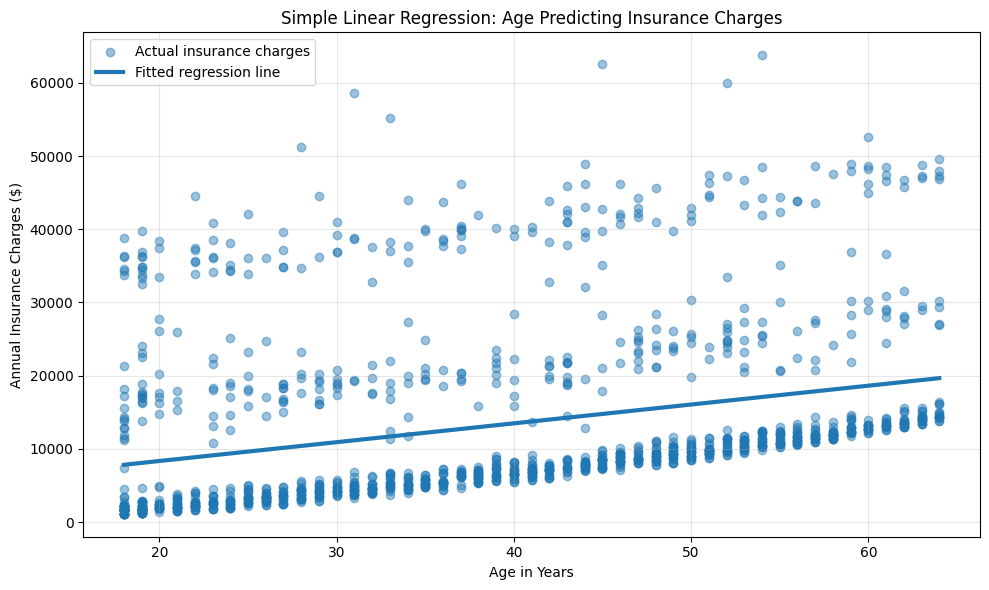

In [23]:
# Sort the data by age so the fitted regression line appears smooth
age_plot_df = insurance_clean_df.sort_values("age")

# Create the scatter plot and fitted regression line
plt.figure(figsize=(10, 6))

plt.scatter(
    insurance_clean_df["age"],
    insurance_clean_df["charges"],
    alpha=0.45,
    label="Actual insurance charges"
)

plt.plot(
    age_plot_df["age"],
    age_plot_df["age_predicted_charges"],
    linewidth=3,
    label="Fitted regression line"
)

plt.title("Simple Linear Regression: Age Predicting Insurance Charges")
plt.xlabel("Age in Years")
plt.ylabel("Annual Insurance Charges ($)")
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure
plt.savefig(
    output_dir / "age_regression_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

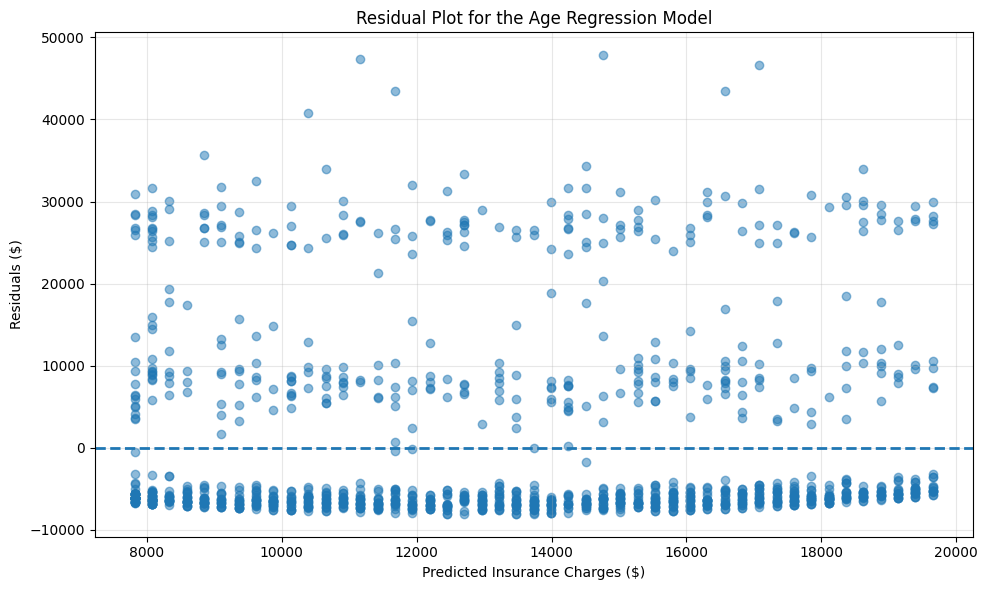

In [24]:
# Create a residual plot for the age regression model
plt.figure(figsize=(10, 6))

plt.scatter(
    insurance_clean_df["age_predicted_charges"],
    insurance_clean_df["age_residuals"],
    alpha=0.50
)

# Add a horizontal reference line at zero
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot for the Age Regression Model")
plt.xlabel("Predicted Insurance Charges ($)")
plt.ylabel("Residuals ($)")
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure
plt.savefig(
    output_dir / "age_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

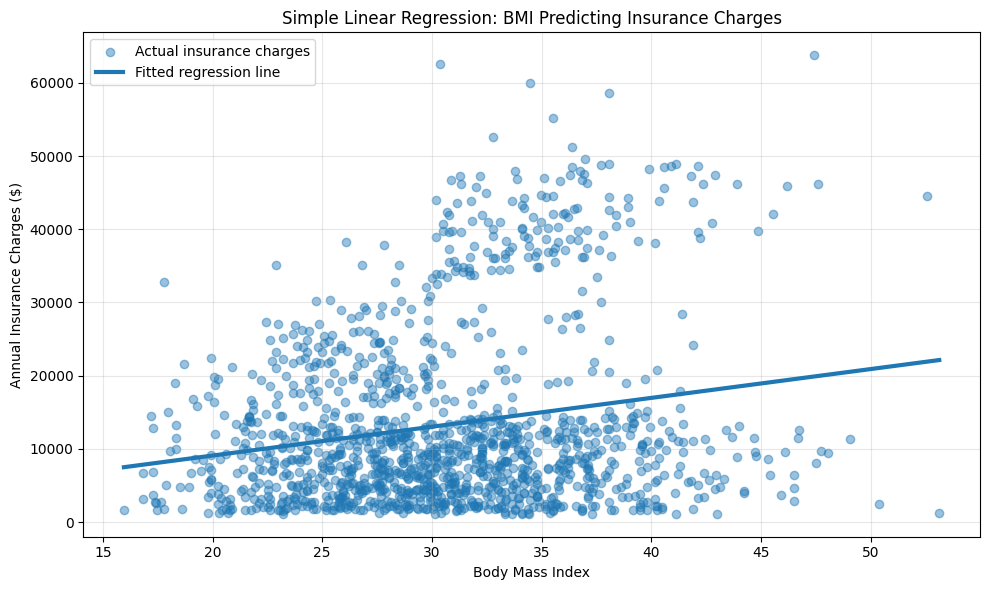

In [25]:
# Sort the data by BMI so the fitted regression line appears smooth
bmi_plot_df = insurance_clean_df.sort_values("bmi")

# Create the scatter plot and fitted regression line
plt.figure(figsize=(10, 6))

plt.scatter(
    insurance_clean_df["bmi"],
    insurance_clean_df["charges"],
    alpha=0.45,
    label="Actual insurance charges"
)

plt.plot(
    bmi_plot_df["bmi"],
    bmi_plot_df["bmi_predicted_charges"],
    linewidth=3,
    label="Fitted regression line"
)

plt.title("Simple Linear Regression: BMI Predicting Insurance Charges")
plt.xlabel("Body Mass Index")
plt.ylabel("Annual Insurance Charges ($)")
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure
plt.savefig(
    output_dir / "bmi_regression_line.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

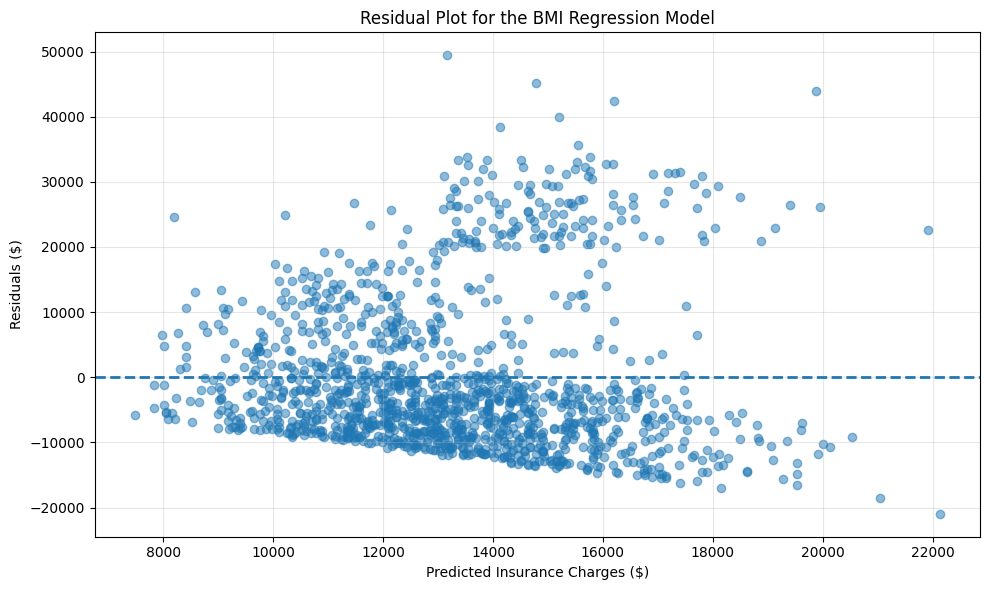

In [26]:
# Create a residual plot for the BMI regression model
plt.figure(figsize=(10, 6))

plt.scatter(
    insurance_clean_df["bmi_predicted_charges"],
    insurance_clean_df["bmi_residuals"],
    alpha=0.50
)

# Add a horizontal reference line at zero
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot for the BMI Regression Model")
plt.xlabel("Predicted Insurance Charges ($)")
plt.ylabel("Residuals ($)")
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure
plt.savefig(
    output_dir / "bmi_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

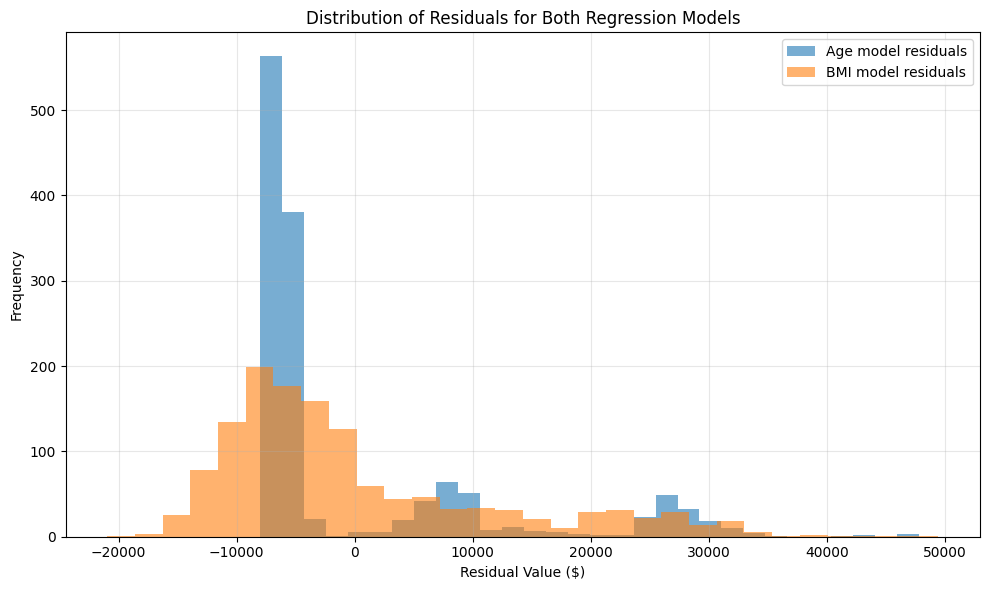

In [27]:
# Compare the distributions of residuals from both regression models
plt.figure(figsize=(10, 6))

plt.hist(
    insurance_clean_df["age_residuals"],
    bins=30,
    alpha=0.60,
    label="Age model residuals"
)

plt.hist(
    insurance_clean_df["bmi_residuals"],
    bins=30,
    alpha=0.60,
    label="BMI model residuals"
)

plt.title("Distribution of Residuals for Both Regression Models")
plt.xlabel("Residual Value ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.30)
plt.tight_layout()

# Save the figure
plt.savefig(
    output_dir / "residual_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Model Comparison

The two simple linear regression models are compared using their coefficients, p-values, coefficient of determination (\(R^2\)), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

- A larger \(R^2\) indicates that the predictor explains more variation in insurance charges.
- A smaller MAE indicates lower average prediction error.
- A smaller RMSE indicates fewer large prediction errors.
- A p-value below 0.05 indicates that the predictor has a statistically significant linear relationship with insurance charges.

In [28]:
# Create a table containing the main results from both regression models
model_comparison = pd.DataFrame({
    "Model": [
        "Age predicting charges",
        "BMI predicting charges"
    ],
    "Predictor": [
        "Age",
        "BMI"
    ],
    "Intercept": [
        age_intercept,
        bmi_intercept
    ],
    "Coefficient": [
        age_coefficient,
        bmi_coefficient
    ],
    "P_Value": [
        age_p_value,
        bmi_p_value
    ],
    "R_Squared": [
        age_r_squared,
        bmi_r_squared
    ],
    "MAE": [
        age_mae,
        bmi_mae
    ],
    "RMSE": [
        age_rmse,
        bmi_rmse
    ]
})

# Create a formatted copy for display
model_comparison_display = model_comparison.copy()

model_comparison_display["Intercept"] = (
    model_comparison_display["Intercept"].round(2)
)

model_comparison_display["Coefficient"] = (
    model_comparison_display["Coefficient"].round(2)
)

model_comparison_display["P_Value"] = (
    model_comparison_display["P_Value"].map(lambda value: f"{value:.3e}")
)

model_comparison_display["R_Squared"] = (
    model_comparison_display["R_Squared"].round(4)
)

model_comparison_display["MAE"] = (
    model_comparison_display["MAE"].round(2)
)

model_comparison_display["RMSE"] = (
    model_comparison_display["RMSE"].round(2)
)

model_comparison_display

,Model,Predictor,Intercept,Coefficient,P_Value,R_Squared,MAE,RMSE
0,Age predicting charges,Age,3190.02,257.23,6.976e-29,0.0890,9059.15,11554.65
1,BMI predicting charges,BMI,1202.14,393.86,2.468e-13,0.0394,9173.49,11865.18


In [29]:
# Identify the model with the larger R-squared value
best_r_squared_model = model_comparison.loc[
    model_comparison["R_Squared"].idxmax(),
    "Model"
]

# Identify the model with the lowest MAE
best_mae_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

# Identify the model with the lowest RMSE
best_rmse_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

print("MODEL COMPARISON RESULTS")
print("-" * 50)
print(f"Highest R-squared: {best_r_squared_model}")
print(f"Lowest MAE: {best_mae_model}")
print(f"Lowest RMSE: {best_rmse_model}")

print("\nOverall finding:")
print(
    "Age provides a stronger simple linear regression model than BMI, "
    "but neither predictor explains a large proportion of the variation "
    "in insurance charges."
)

MODEL COMPARISON RESULTS
--------------------------------------------------
Highest R-squared: Age predicting charges
Lowest MAE: Age predicting charges
Lowest RMSE: Age predicting charges

Overall finding:
Age provides a stronger simple linear regression model than BMI, but neither predictor explains a large proportion of the variation in insurance charges.


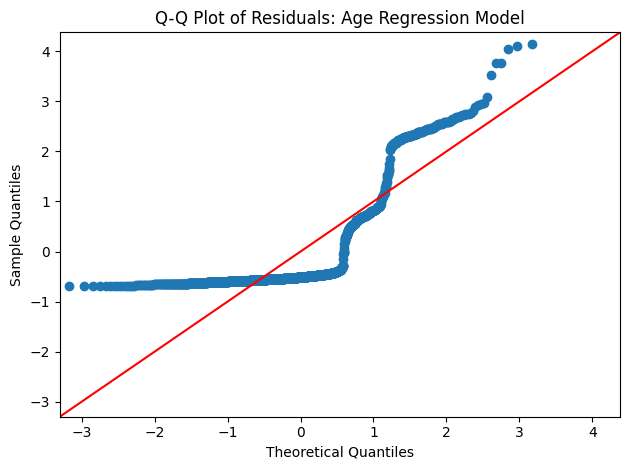

In [30]:
# Create a Q-Q plot to examine the normality of age-model residuals
fig = sm.qqplot(
    insurance_clean_df["age_residuals"],
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals: Age Regression Model")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.tight_layout()

plt.savefig(
    output_dir / "age_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

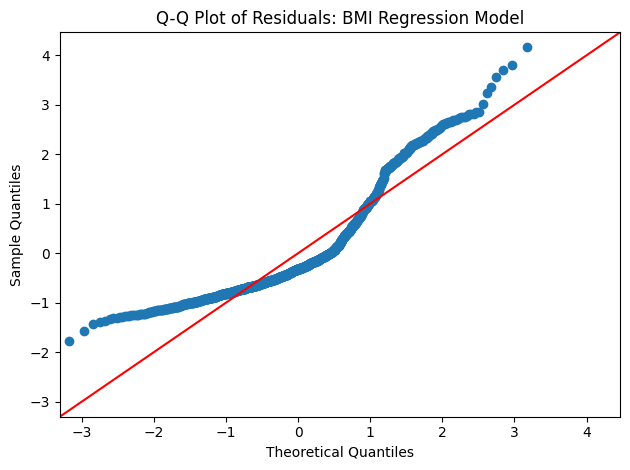

In [31]:
# Create a Q-Q plot to examine the normality of BMI-model residuals
fig = sm.qqplot(
    insurance_clean_df["bmi_residuals"],
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals: BMI Regression Model")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.tight_layout()

plt.savefig(
    output_dir / "bmi_residual_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# Save the model comparison results as a CSV file
model_comparison.to_csv(
    output_dir / "linear_regression_model_comparison.csv",
    index=False
)

# Save the cleaned dataset with predicted values and residuals
insurance_clean_df.to_csv(
    output_dir / "insurance_regression_results.csv",
    index=False
)

print("Model comparison saved successfully.")
print("Insurance regression results saved successfully.")

Model comparison saved successfully.
Insurance regression results saved successfully.


In [33]:
# Save the complete Statsmodels summaries as text files
with open(
    output_dir / "age_regression_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(age_model.summary().as_text())

with open(
    output_dir / "bmi_regression_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(bmi_model.summary().as_text())

print("Regression model summaries saved successfully.")

Regression model summaries saved successfully.


## 6. Conclusions

This analysis used simple linear regression to investigate whether age and BMI significantly predict annual medical insurance charges.

For the first research question, the age coefficient was positive and statistically significant. Therefore, the null hypothesis was rejected. The model indicated that annual insurance charges increased by approximately $257 for each additional year of age. However, the model explained only about 8.9% of the variation in insurance charges.

For the second research question, the BMI coefficient was also positive and statistically significant. Therefore, the null hypothesis was rejected. The model indicated that annual insurance charges increased by approximately $394 for each one-unit increase in BMI. BMI alone explained approximately 3.9% of the variation in insurance charges.

The age model produced a larger R-squared value and lower prediction errors than the BMI model. Therefore, age was the stronger of the two individual predictors. Nevertheless, both models had low explanatory power and relatively large residuals. The scatter plots, residual plots, and Q-Q plots showed that insurance charges are influenced by additional factors not included in these simple regression models.

Variables such as smoking status, sex, geographic region, and number of children may help explain the remaining variation. A future analysis could use multiple linear regression to combine these factors and potentially produce more accurate insurance-charge predictions.

## 7. Supporting References

James, G., Witten, D., Hastie, T., Tibshirani, R., and Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*. Springer.

Pandas Development Team. (2026). *Pandas documentation*. https://pandas.pydata.org/docs/

Seabold, S., and Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96).

Scikit-learn Developers. (2026). *Scikit-learn documentation*. https://scikit-learn.org/stable/

The dataset used in this project contains demographic, health, and insurance-charge information for 1,338 insurance customers.